# 🌿 CO₂ Emission Prediction
**Model:** Gradient Boosting Regressor  
**Target:** CO₂ Emissions (g/km)  
**Features:** Engine Size, Cylinders, Fuel Consumption

## 1. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

Imports done


In [ ]:
# ── Color theme ──────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0d1a0e',
    'axes.facecolor':    '#0d1a0e',
    'axes.edgecolor':    '#2e7d32',
    'axes.labelcolor':   '#a5d6a7',
    'xtick.color':       '#81c784',
    'ytick.color':       '#81c784',
    'text.color':        '#e8f5e9',
    'grid.color':        '#1e4d22',
    'grid.linestyle':    '--',
    'grid.alpha':        0.5,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'font.family':       'monospace'
})

GREEN = '#4caf50'
GREEN_PALETTE = ['#1b5e20','#2e7d32','#388e3c','#43a047',
                 '#4caf50','#66bb6a','#81c784','#a5d6a7']

Imports done


## 2. Load Data

In [2]:
# Load dataset
df = pd.read_csv('D:\My GitHub Repo\CO2-Emission-Prediction-and-Analysis-main\co2 Emissions.csv')
print('Shape:', df.shape)
df.head()

Shape: (7385, 12)


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

In [4]:
print('Null values:')
print(df.isnull().sum())

Null values:
Make                                0
Model                               0
Vehicle Class                       0
Engine Size(L)                      0
Cylinders                           0
Transmission                        0
Fuel Type                           0
Fuel Consumption City (L/100 km)    0
Fuel Consumption Hwy (L/100 km)     0
Fuel Consumption Comb (L/100 km)    0
Fuel Consumption Comb (mpg)         0
CO2 Emissions(g/km)                 0
dtype: int64


In [5]:
df.describe()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
count,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000
mean,3.160068,5.615030,12.556534,9.041706,10.975071,27.481652,250.584699
std,1.354170,1.828307,3.500274,2.224456,2.892506,7.231879,58.512679
min,0.900000,3.000000,4.200000,4.000000,4.100000,11.000000,96.000000
25%,2.000000,4.000000,10.100000,7.500000,8.900000,22.000000,208.000000
50%,3.000000,6.000000,12.100000,8.700000,10.600000,27.000000,246.000000
75%,3.700000,6.000000,14.600000,10.200000,12.600000,32.000000,288.000000
max,8.400000,16.000000,30.600000,20.600000,26.100000,69.000000,522.000000


## 3. Exploratory Data Analysis

In [6]:
fuel_map = {'Z': 'Premium Gasoline', 'X': 'Regular Gasoline',
            'D': 'Diesel', 'E': 'Ethanol(E85)', 'N': 'Natural Gas'}
df['Fuel Type'] = df['Fuel Type'].map(fuel_map)
df['Fuel Type'].value_counts()

Fuel Type
Regular Gasoline    3637
Premium Gasoline    3202
Ethanol(E85)         370
Diesel               175
Natural Gas            1
Name: count, dtype: int64

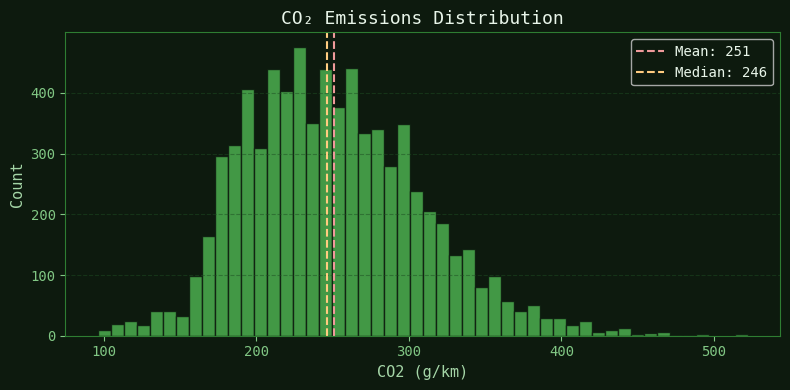

In [35]:
# CO2 distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['CO2 Emissions(g/km)'], bins=50, color=GREEN, edgecolor='#0d1a0e', alpha=0.85)
ax.axvline(df['CO2 Emissions(g/km)'].mean(),   color='#ef9a9a', linestyle='--', linewidth=1.5, label=f'Mean: {df["CO2 Emissions(g/km)"].mean():.0f}')
ax.axvline(df['CO2 Emissions(g/km)'].median(), color='#ffcc80', linestyle='--', linewidth=1.5, label=f'Median: {df["CO2 Emissions(g/km)"].median():.0f}')
ax.set_xlabel('CO2 (g/km)')
ax.set_ylabel('Count')
ax.set_title('CO₂ Emissions Distribution')
ax.legend()
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

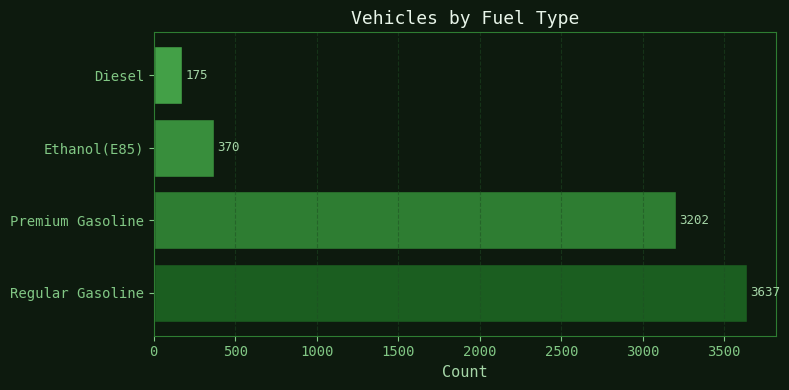

In [21]:
# Fuel type count
fuel_counts = df['Fuel Type'].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(fuel_counts.index, fuel_counts.values,
               color=GREEN_PALETTE[:len(fuel_counts)], edgecolor='#0d1a0e')
for bar, val in zip(bars, fuel_counts.values):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            str(val), va='center', color='#a5d6a7', fontsize=9)
ax.set_xlabel('Count')
ax.set_title('Vehicles by Fuel Type')
ax.grid(True, axis='x')
plt.tight_layout()
plt.show()

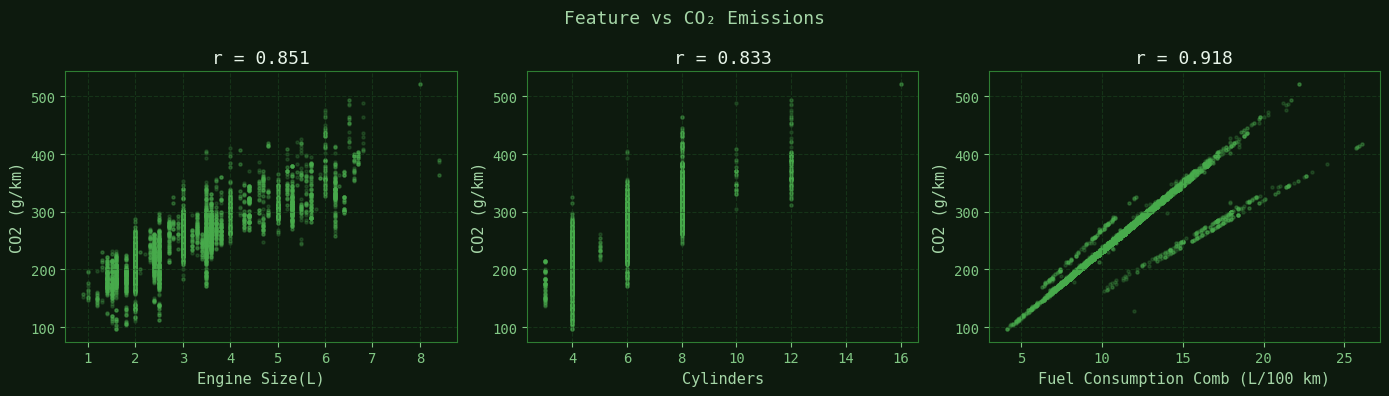

In [22]:
# Scatter plots — features vs CO2
features = ['Engine Size(L)', 'Cylinders', 'Fuel Consumption Comb (L/100 km)']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Feature vs CO₂ Emissions', color='#a5d6a7', fontsize=13)

for ax, col in zip(axes, features):
    ax.scatter(df[col], df['CO2 Emissions(g/km)'],
               alpha=0.2, s=5, color=GREEN, rasterized=True)
    corr = df[col].corr(df['CO2 Emissions(g/km)'])
    ax.set_xlabel(col)
    ax.set_ylabel('CO2 (g/km)')
    ax.set_title(f'r = {corr:.3f}')
    ax.grid(True)

plt.tight_layout()
plt.show()

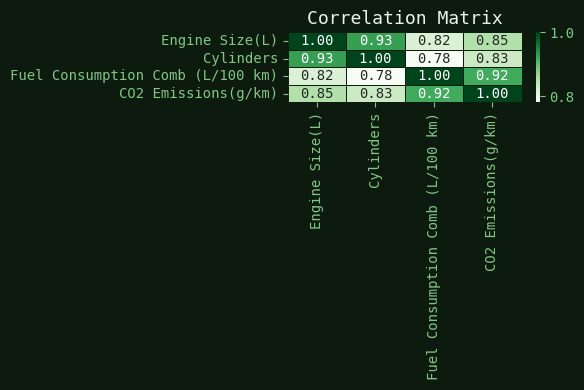

In [23]:
# Correlation heatmap
num_cols = ['Engine Size(L)', 'Cylinders',
            'Fuel Consumption Comb (L/100 km)', 'CO2 Emissions(g/km)']

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='Greens',
            linewidths=0.5, linecolor='#0d1a0e', ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [24]:
# Remove Natural Gas (very few samples)
df = df[df['Fuel Type'] != 'Natural Gas'].reset_index(drop=True)

# Select features and target
df_model = df[['Engine Size(L)', 'Cylinders',
               'Fuel Consumption Comb (L/100 km)', 'CO2 Emissions(g/km)']].copy()

# Remove outliers using Z-score
z_scores = np.abs(stats.zscore(df_model))
df_model = df_model[(z_scores < 1.9).all(axis=1)].reset_index(drop=True)

print('Final dataset shape:', df_model.shape)
df_model.head()

Final dataset shape: (6509, 4)


,Engine Size(L),Cylinders,Fuel Consumption Comb (L/100 km),CO2 Emissions(g/km)
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,3.5,6,11.1,255
3,3.5,6,10.6,244
4,3.5,6,10.0,230


In [25]:
X = df_model[['Engine Size(L)', 'Cylinders', 'Fuel Consumption Comb (L/100 km)']]
y = df_model['CO2 Emissions(g/km)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)

X_train: (5207, 3)
X_test : (1302, 3)


## 5. Gradient Boosting Model

In [26]:
model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                   max_depth=4, random_state=42)
model.fit(X_train, y_train)
print('Model trained successfully')

Model trained successfully


In [27]:
y_pred = model.predict(X_test)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'R² Score : {r2:.4f}')
print(f'MAE      : {mae:.2f} g/km')
print(f'RMSE     : {rmse:.2f} g/km')

R² Score : 0.9745
MAE      : 3.45 g/km
RMSE     : 7.36 g/km


## 6. Results & Visualization

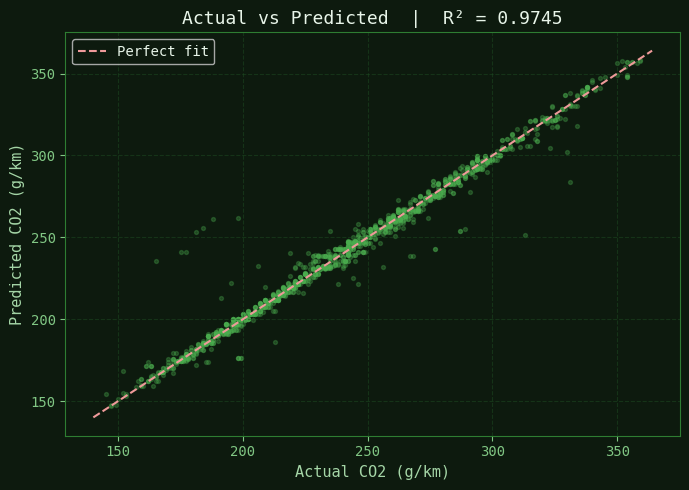

In [28]:
# Actual vs Predicted
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test, y_pred, alpha=0.3, s=8, color=GREEN, rasterized=True)
lims = [y_test.min() - 5, y_test.max() + 5]
ax.plot(lims, lims, color='#ef9a9a', linestyle='--', linewidth=1.5, label='Perfect fit')
ax.set_xlabel('Actual CO2 (g/km)')
ax.set_ylabel('Predicted CO2 (g/km)')
ax.set_title(f'Actual vs Predicted  |  R² = {r2:.4f}')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

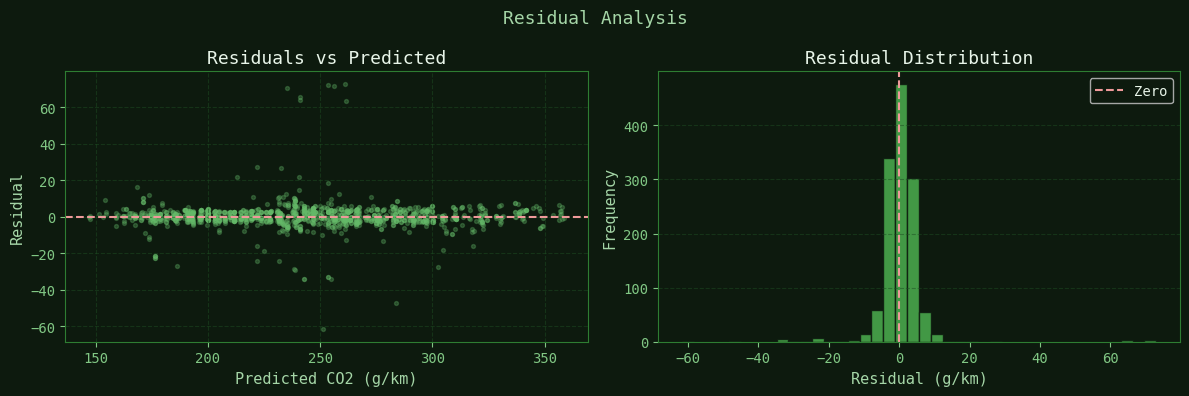

In [16]:
# Residual plot
residuals = y_pred - y_test.values

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Residual Analysis', color='#a5d6a7', fontsize=13)

axes[0].scatter(y_pred, residuals, alpha=0.3, s=8, color='#66bb6a', rasterized=True)
axes[0].axhline(0, color='#ef9a9a', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted CO2 (g/km)')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted')
axes[0].grid(True)

axes[1].hist(residuals, bins=40, color=GREEN, edgecolor='#0d1a0e', alpha=0.85)
axes[1].axvline(0, color='#ef9a9a', linestyle='--', linewidth=1.5, label='Zero')
axes[1].set_xlabel('Residual (g/km)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')
axes[1].legend()
axes[1].grid(True, axis='y')

plt.tight_layout()
plt.show()

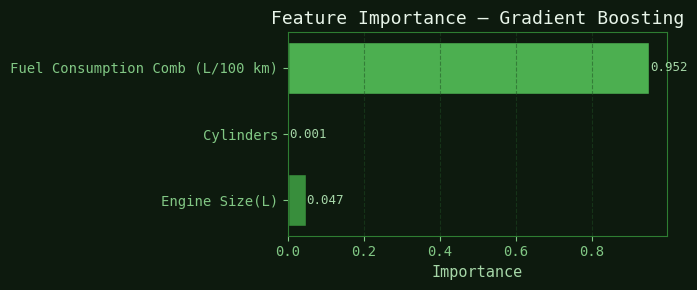

In [17]:
# Feature importance
importance = model.feature_importances_
feat_names = X.columns

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(feat_names, importance, color=GREEN_PALETTE[2:5], edgecolor='#0d1a0e')
for bar, val in zip(bars, importance):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', color='#a5d6a7', fontsize=9)
ax.set_xlabel('Importance')
ax.set_title('Feature Importance — Gradient Boosting')
ax.grid(True, axis='x')
plt.tight_layout()
plt.show()

In [18]:
# Prediction sample table
results_df = pd.DataFrame({
    'Actual':     y_test.values,
    'Predicted':  np.round(y_pred, 2),
    'Difference': np.round(y_pred - y_test.values, 2)
}).reset_index(drop=True)

results_df.head(20)

,Actual,Predicted,Difference
0,288,291.36,3.36
1,270,267.36,-2.64
2,244,242.64,-1.36
3,167,167.42,0.42
4,191,212.87,21.87
5,223,225.85,2.85
6,197,196.27,-0.73
7,219,240.67,21.67
8,268,265.91,-2.09
9,194,192.94,-1.06


## 7. Predict on New Input

In [19]:
# Enter your vehicle values below
engine_size      = 3.0   # litres
cylinders        = 6     # number of cylinders
fuel_consumption = 10.5  # L/100 km

new_input = pd.DataFrame([[engine_size, cylinders, fuel_consumption]],
                          columns=['Engine Size(L)', 'Cylinders',
                                   'Fuel Consumption Comb (L/100 km)'])

prediction = model.predict(new_input)[0]
print(f'Predicted CO2 Emission: {prediction:.2f} g/km')

Predicted CO2 Emission: 247.67 g/km
